In [1]:
import pandas as pd

health_clean = pd.read_csv("../data/places_clean.csv")
core = ["DIABETES_CrudePrev", "OBESITY_CrudePrev", "ACCESS2_CrudePrev", "CSMOKING_CrudePrev"]

health_clean[core + ["FOODINSECU_CrudePrev"]].describe()

,DIABETES_CrudePrev,OBESITY_CrudePrev,ACCESS2_CrudePrev,CSMOKING_CrudePrev,FOODINSECU_CrudePrev
count,2956.000000,2956.000000,2956.000000,2956.000000,2299.000000
mean,13.638363,37.423748,11.141509,15.818708,16.267551
std,2.777303,4.754086,4.712733,3.477471,5.952448
min,4.900000,16.700000,3.600000,6.400000,5.700000
25%,11.800000,34.900000,8.100000,13.500000,12.000000
50%,13.300000,37.900000,9.900000,15.500000,14.800000
75%,15.200000,40.400000,12.800000,17.800000,18.950000
max,27.100000,52.900000,43.500000,39.800000,46.600000


In [2]:
# does insurance access or food insecurity correlate with disease outcomes?
health_clean[core + ["FOODINSECU_CrudePrev"]].corr()

,DIABETES_CrudePrev,OBESITY_CrudePrev,ACCESS2_CrudePrev,CSMOKING_CrudePrev,FOODINSECU_CrudePrev
DIABETES_CrudePrev,1.000000,0.670452,0.450353,0.714455,0.772273
OBESITY_CrudePrev,0.670452,1.000000,0.238679,0.721894,0.544794
ACCESS2_CrudePrev,0.450353,0.238679,1.000000,0.222960,0.742484
CSMOKING_CrudePrev,0.714455,0.721894,0.222960,1.000000,0.660086
FOODINSECU_CrudePrev,0.772273,0.544794,0.742484,0.660086,1.000000


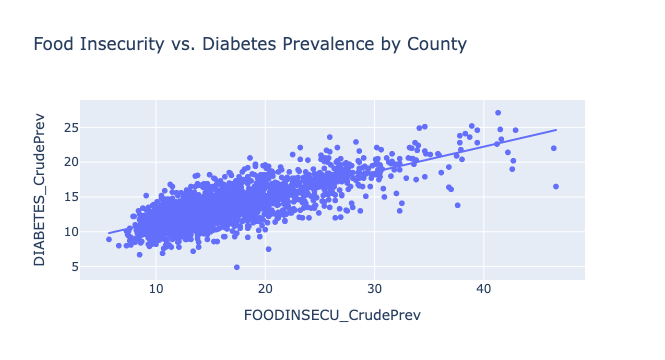

In [3]:
import plotly.express as px

fig = px.scatter(
    health_clean, x="FOODINSECU_CrudePrev", y="DIABETES_CrudePrev",
    hover_data=["CountyName", "StateAbbr"],
    trendline="ols",
    title="Food Insecurity vs. Diabetes Prevalence by County"
)
fig.show()

In [4]:
# state level 
state_summary = health_clean.groupby("StateDesc")[core + ["FOODINSECU_CrudePrev"]].mean().round(1)
state_summary.sort_values("DIABETES_CrudePrev", ascending=False).head(10)

,DIABETES_CrudePrev,OBESITY_CrudePrev,ACCESS2_CrudePrev,CSMOKING_CrudePrev,FOODINSECU_CrudePrev
StateDesc,,,,,
Mississippi,17.2,42.5,12.7,18.8,25.8
West Virginia,17.0,41.4,9.0,20.8,17.0
Alabama,16.8,41.7,11.2,17.4,22.7
Louisiana,16.5,42.1,9.8,19.7,25.3
South Carolina,16.5,39.0,13.3,15.5,22.0
Georgia,15.6,38.5,14.7,16.9,20.9
Arkansas,15.3,40.9,11.9,18.1,20.9
Tennessee,15.1,40.0,12.6,20.3,NaN
New Mexico,15.0,34.8,16.6,14.3,22.1


In [5]:
# check on tennessee and tx NaN
health_clean[health_clean["StateDesc"] == "Tennessee"]["FOODINSECU_CrudePrev"].isna().all()
health_clean[health_clean["StateDesc"] == "Texas"]["FOODINSECU_CrudePrev"].isna().all()

np.True_

In [6]:
import statsmodels.formula.api as smf

model = smf.ols(
    "DIABETES_CrudePrev ~ OBESITY_CrudePrev + ACCESS2_CrudePrev + CSMOKING_CrudePrev + FOODINSECU_CrudePrev",
    data=health_clean
).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:     DIABETES_CrudePrev   R-squared:                       0.707
Model:                            OLS   Adj. R-squared:                  0.706
Method:                 Least Squares   F-statistic:                     1382.
Date:                Tue, 04 Aug 2026   Prob (F-statistic):               0.00
Time:                        15:21:16   Log-Likelihood:                -4211.2
No. Observations:                2299   AIC:                             8432.
Df Residuals:                    2294   BIC:                             8461.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
Intercept                1.7802 

## Finding: Food insecurity is the strongest predictor of diabetes prevalence 

Across all US counties in this dataset, food insecurity was a more consistent predictor of diabetes prevalence than obesity, smoking, or insurance- even after controlling for all three at the same time. 

The simple correlation matrix showed that diabetes was related to obesity (0.67), smoking (0.71), food insecurity (0.77), and lack of insurance (0.45). Correlation alone cannot tell whether these factors matter independently, or whether some are just riding along with eachother. Running a multiple regression showed: 

- Obesity, smoking, and food insecurity were all statistically significant independent predictors (p < 0.001), with food insecurity having the largest effect of the three.
- Lack of health insurance (Access2) was **not** statistically significant (p = 0.076) once the other factors were accounted for, despite its moderate correlation with diabetes on its own.

The likely explanation is confounding: insurance access and food insecurity are themselves highly correlated (0.74), so a lot of what looked like "insurance's effect" in the simple correlation was actually food insecurity's effect showing up alongside it. Once food insecurity is in the model, insurance access adds little additional explanatory power of its own. 

**Caveat:** this is county-level (ecological) data — averages across entire counties,not individual patient records — so this doesn't prove that any individual person's food insecurity causes their diabetes. It shows a strong population-level pattern, which is still useful for things like public health resource allocation, but it's not a clinical or causal claim.